In [10]:
import numpy as np
import pandas as pd
import psycopg2
import umap
import matplotlib.pyplot as plt
from pathlib import Path

In [19]:
frag_embeds = np.load('./0.1_embeds.npy')
real_embeds = np.load('./embeddings_superfamily_centroids.npy')

In [20]:
# merge into a df with labels
df_frag = pd.DataFrame(frag_embeds)
df_frag['label'] = 'fragment'
df_real = pd.DataFrame(real_embeds)
df_real['label'] = 'real'
df = pd.concat([df_frag, df_real], ignore_index=True)

In [21]:
reducer = umap.UMAP(random_state=42)
reduced = reducer.fit_transform(df.drop('label', axis=1))
df['umap1'] = reduced[:, 0]
df['umap2'] = reduced[:, 1]

c:\Users\oscar\Documents\IJF\igem-toronto\resources\260531_issue79_esmc_testing\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0         fragment
1         fragment
2         fragment
3         fragment
4         fragment
            ...   
133405        real
133406        real
133407        real
133408        real
133409        real
Name: label, Length: 133410, dtype: str

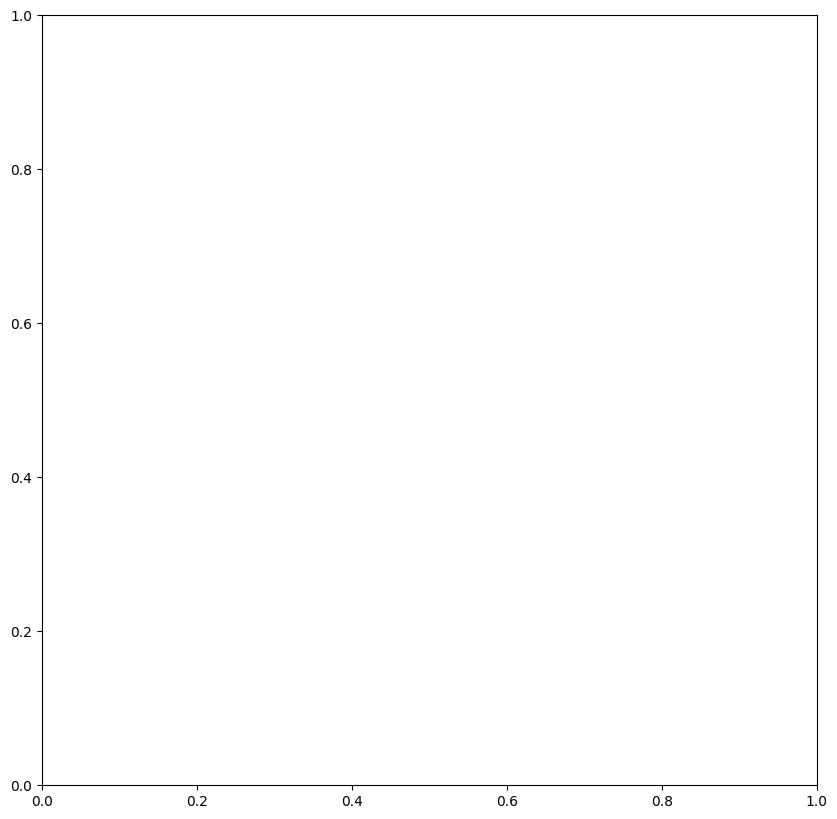

In [ ]:
plt.figure(figsize=(10, 10))

plt.scatter(df['umap1'], df['umap2'], s=5, alpha=0.5, c=df['label'].map({'fragment': 'blue', 'real': 'orange'}))
plt.title('UMAP Projection of Protein Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()